In [1]:
# ============================================================
# CURVATURE-ADAPTED LANGEVIN (STANDALONE NOTEBOOK CELL)
# 4D 1-form Maxwell + quartic, FFT curlcurl, GPU-only
#
# NEW DYNAMICS:
#   dA = - H_phys^{-1/2} ∇S dt + sqrt(2) H_phys^{-1/2} dW
#
# Uses:
#   - exact FFT curlcurl
#   - exact gradient
#   - Lanczos estimate of lowest physical stiffness
# ============================================================

import math
import torch
import torch.fft as fft

# ----------------------------
# DEVICE
# ----------------------------
assert torch.cuda.is_available(), "CUDA required"
device = "cuda"
torch.set_default_dtype(torch.float64)

# ----------------------------
# PARAMETERS
# ----------------------------
L = 16
d = 4
m2 = 0.30
alpha = 1.0
lam4 = 0.5

dt = 2e-4
steps = 3000
burnin = 500
lanczos_iters = 20
eps_reg = 1e-6

# ----------------------------
# FFT MOMENTUM
# ----------------------------
freq = torch.fft.fftfreq(L, device=device)
ph = 2.0 * torch.sin(math.pi * freq)

p0 = ph.view(L,1,1,1)
p1 = ph.view(1,L,1,1)
p2 = ph.view(1,1,L,1)
p3 = ph.view(1,1,1,L)
p2grid = p0*p0 + p1*p1 + p2*p2 + p3*p3

# ----------------------------
# FIELD INITIALIZATION
# ----------------------------
A = 0.1 * torch.randn((d, L, L, L, L), device=device)

# ----------------------------
# CURLCURL + PROJECTION
# ----------------------------
def curlcurl(A):
    Ahat = fft.fftn(A, dim=(1,2,3,4), norm="ortho")
    dot = p0*Ahat[0] + p1*Ahat[1] + p2*Ahat[2] + p3*Ahat[3]

    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / p2grid[mask]

    fac = dot * inv
    Aperp = torch.stack([
        Ahat[0] - p0*fac,
        Ahat[1] - p1*fac,
        Ahat[2] - p2*fac,
        Ahat[3] - p3*fac,
    ], dim=0)

    cc_hat = Aperp * p2grid
    return fft.ifftn(cc_hat, dim=(1,2,3,4), norm="ortho").real

# ----------------------------
# ACTION + GRADIENT
# ----------------------------
def grad_S(A):
    cc = curlcurl(A)
    return m2*A + alpha*cc + lam4*(A**3)

def action_S(A):
    cc = curlcurl(A)
    return (
        0.5*m2*(A*A).sum()
        + 0.5*alpha*(A*cc).sum()
        + 0.25*lam4*(A**4).sum()
    )

# ----------------------------
# HESSIAN–VECTOR PRODUCT (PHYSICAL)
# ----------------------------
def hvp(A, v):
    cc_v = curlcurl(v)
    return m2*v + alpha*cc_v + 3.0*lam4*(A*A)*v

# ----------------------------
# LOWEST PHYSICAL STIFFNESS (LANCZOS)
# ----------------------------
def lambda_min_phys(A):
    q = torch.randn_like(A)
    q = q / torch.norm(q)
    q_prev = torch.zeros_like(q)

    alphas = []
    betas = []

    for _ in range(lanczos_iters):
        z = hvp(A, q)
        a = (q*z).sum()
        z = z - a*q - (betas[-1]*q_prev if betas else 0)
        b = torch.norm(z)

        alphas.append(a.item())
        betas.append(b.item())

        q_prev = q
        q = z / (b + 1e-30)

    T = torch.diag(torch.tensor(alphas, device=device))
    if len(betas) > 1:
        off = torch.tensor(betas[:-1], device=device)
        T += torch.diag(off, 1) + torch.diag(off, -1)

    return torch.linalg.eigvalsh(T).min()

# ----------------------------
# MAIN DYNAMICS
# ----------------------------
for t in range(steps):
    g = grad_S(A)
    lam = lambda_min_phys(A)
    scale = 1.0 / torch.sqrt(lam + eps_reg)

    noise = torch.randn_like(A)

    A = (
        A
        - dt * scale * g
        + math.sqrt(2.0*dt) * scale * noise
    )

    if (t+1) % 500 == 0:
        with torch.no_grad():
            print(f"[step {t+1}/{steps}] "
                  f"lambda_min={lam.item():.6f}  "
                  f"S={action_S(A).item():.3e}")

print("done")


[step 500/3000] lambda_min=0.430856  S=1.509e+05
[step 1000/3000] lambda_min=0.455319  S=1.611e+05
[step 1500/3000] lambda_min=0.472470  S=1.633e+05
[step 2000/3000] lambda_min=0.481023  S=1.648e+05
[step 2500/3000] lambda_min=0.486024  S=1.650e+05
[step 3000/3000] lambda_min=0.493283  S=1.657e+05
done


In [2]:
# ============================================================
# CONTROL RUN: STANDARD LANGEVIN (NO CURVATURE ADAPTATION)
# Drop-in standalone notebook cell
# ============================================================

import math
import torch
import torch.fft as fft

assert torch.cuda.is_available()
device = "cuda"
torch.set_default_dtype(torch.float64)

# ----------------------------
# PARAMETERS (MATCH ADAPTED RUN)
# ----------------------------
L = 16
d = 4
m2 = 0.30
alpha = 1.0
lam4 = 0.5

dt = 2e-4
steps = 3000
burnin = 500
lanczos_iters = 20

# ----------------------------
# FFT MOMENTUM
# ----------------------------
freq = torch.fft.fftfreq(L, device=device)
ph = 2.0 * torch.sin(math.pi * freq)

p0 = ph.view(L,1,1,1)
p1 = ph.view(1,L,1,1)
p2 = ph.view(1,1,L,1)
p3 = ph.view(1,1,1,L)
p2grid = p0*p0 + p1*p1 + p2*p2 + p3*p3

# ----------------------------
# FIELD INITIALIZATION
# ----------------------------
torch.manual_seed(0)
A = 0.1 * torch.randn((d, L, L, L, L), device=device)

# ----------------------------
# CURLCURL
# ----------------------------
def curlcurl(A):
    Ahat = fft.fftn(A, dim=(1,2,3,4), norm="ortho")
    dot = p0*Ahat[0] + p1*Ahat[1] + p2*Ahat[2] + p3*Ahat[3]

    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / p2grid[mask]

    fac = dot * inv
    Aperp = torch.stack([
        Ahat[0] - p0*fac,
        Ahat[1] - p1*fac,
        Ahat[2] - p2*fac,
        Ahat[3] - p3*fac,
    ], dim=0)

    cc_hat = Aperp * p2grid
    return fft.ifftn(cc_hat, dim=(1,2,3,4), norm="ortho").real

# ----------------------------
# ACTION + GRAD
# ----------------------------
def grad_S(A):
    cc = curlcurl(A)
    return m2*A + alpha*cc + lam4*(A**3)

def action_S(A):
    cc = curlcurl(A)
    return (
        0.5*m2*(A*A).sum()
        + 0.5*alpha*(A*cc).sum()
        + 0.25*lam4*(A**4).sum()
    )

# ----------------------------
# HESSIAN–VECTOR PRODUCT
# ----------------------------
def hvp(A, v):
    cc_v = curlcurl(v)
    return m2*v + alpha*cc_v + 3.0*lam4*(A*A)*v

# ----------------------------
# LANCZOS (FOR LOGGING ONLY)
# ----------------------------
def lambda_min_phys(A):
    q = torch.randn_like(A)
    q = q / torch.norm(q)
    q_prev = torch.zeros_like(q)

    alphas = []
    betas = []

    for _ in range(lanczos_iters):
        z = hvp(A, q)
        a = (q*z).sum()
        z = z - a*q - (betas[-1]*q_prev if betas else 0)
        b = torch.norm(z)

        alphas.append(a.item())
        betas.append(b.item())

        q_prev = q
        q = z / (b + 1e-30)

    T = torch.diag(torch.tensor(alphas, device=device))
    if len(betas) > 1:
        off = torch.tensor(betas[:-1], device=device)
        T += torch.diag(off, 1) + torch.diag(off, -1)

    return torch.linalg.eigvalsh(T).min()

# ----------------------------
# MAIN DYNAMICS (STANDARD)
# ----------------------------
for t in range(steps):
    g = grad_S(A)
    noise = torch.randn_like(A)

    A = (
        A
        - dt * g
        + math.sqrt(2.0*dt) * noise
    )

    if (t+1) % 500 == 0:
        with torch.no_grad():
            lam = lambda_min_phys(A)
            print(f"[step {t+1}/{steps}] "
                  f"lambda_min={lam.item():.6f}  "
                  f"S={action_S(A).item():.3e}")

print("done")


[step 500/3000] lambda_min=0.379936  S=8.288e+04
[step 1000/3000] lambda_min=0.401478  S=1.008e+05
[step 1500/3000] lambda_min=0.416162  S=1.072e+05
[step 2000/3000] lambda_min=0.426317  S=1.099e+05
[step 2500/3000] lambda_min=0.434017  S=1.120e+05
[step 3000/3000] lambda_min=0.440564  S=1.135e+05
done


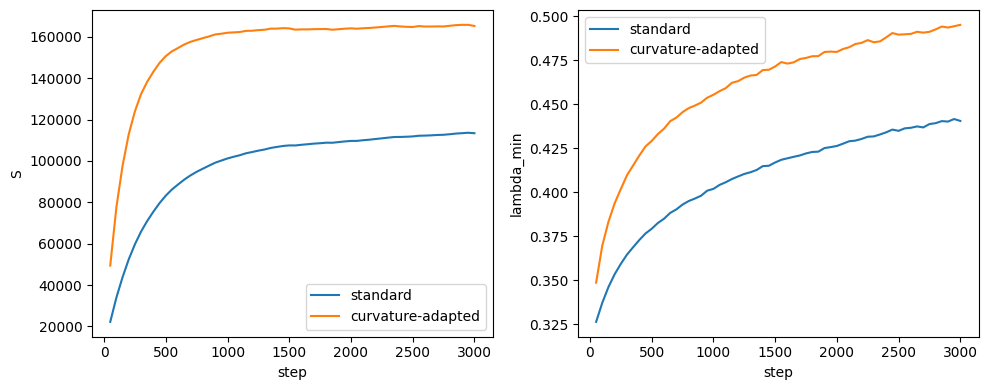

In [3]:
# ============================================================
# SIDE-BY-SIDE COMPARISON RUN + PLOT (STANDALONE)
# Standard vs Curvature-Adapted Langevin
# ============================================================

import math
import torch
import torch.fft as fft
import matplotlib.pyplot as plt

assert torch.cuda.is_available()
device = "cuda"
torch.set_default_dtype(torch.float64)

# ----------------------------
# PARAMETERS
# ----------------------------
L = 16
d = 4
m2 = 0.30
alpha = 1.0
lam4 = 0.5

dt = 2e-4
steps = 3000
log_every = 50
lanczos_iters = 20
eps_reg = 1e-6

# ----------------------------
# FFT MOMENTUM
# ----------------------------
freq = torch.fft.fftfreq(L, device=device)
ph = 2.0 * torch.sin(math.pi * freq)

p0 = ph.view(L,1,1,1)
p1 = ph.view(1,L,1,1)
p2 = ph.view(1,1,L,1)
p3 = ph.view(1,1,1,L)
p2grid = p0*p0 + p1*p1 + p2*p2 + p3*p3

# ----------------------------
# OPERATORS
# ----------------------------
def curlcurl(A):
    Ahat = fft.fftn(A, dim=(1,2,3,4), norm="ortho")
    dot = p0*Ahat[0] + p1*Ahat[1] + p2*Ahat[2] + p3*Ahat[3]
    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / p2grid[mask]
    fac = dot * inv
    Aperp = torch.stack([
        Ahat[0] - p0*fac,
        Ahat[1] - p1*fac,
        Ahat[2] - p2*fac,
        Ahat[3] - p3*fac,
    ], dim=0)
    return fft.ifftn(Aperp * p2grid, dim=(1,2,3,4), norm="ortho").real

def grad_S(A):
    return m2*A + alpha*curlcurl(A) + lam4*(A**3)

def action_S(A):
    cc = curlcurl(A)
    return (
        0.5*m2*(A*A).sum()
        + 0.5*alpha*(A*cc).sum()
        + 0.25*lam4*(A**4).sum()
    )

def hvp(A, v):
    return m2*v + alpha*curlcurl(v) + 3.0*lam4*(A*A)*v

def lambda_min_phys(A):
    q = torch.randn_like(A)
    q = q / torch.norm(q)
    q_prev = torch.zeros_like(q)
    alphas, betas = [], []
    for _ in range(lanczos_iters):
        z = hvp(A, q)
        a = (q*z).sum()
        z = z - a*q - (betas[-1]*q_prev if betas else 0)
        b = torch.norm(z)
        alphas.append(a.item())
        betas.append(b.item())
        q_prev = q
        q = z / (b + 1e-30)
    T = torch.diag(torch.tensor(alphas, device=device))
    if len(betas) > 1:
        off = torch.tensor(betas[:-1], device=device)
        T += torch.diag(off, 1) + torch.diag(off, -1)
    return torch.linalg.eigvalsh(T).min()

# ----------------------------
# RUN FUNCTION
# ----------------------------
def run(use_curvature):
    torch.manual_seed(0)
    A = 0.1 * torch.randn((d, L, L, L, L), device=device)
    S_log, lam_log = [], []
    for t in range(steps):
        g = grad_S(A)
        lam = lambda_min_phys(A)
        scale = 1.0 / torch.sqrt(lam + eps_reg) if use_curvature else 1.0
        A = A - dt * scale * g + math.sqrt(2.0*dt) * scale * torch.randn_like(A)
        if (t+1) % log_every == 0:
            S_log.append(action_S(A).item())
            lam_log.append(lam.item())
    return S_log, lam_log

# ----------------------------
# EXECUTE
# ----------------------------
S_std, lam_std = run(use_curvature=False)
S_curv, lam_curv = run(use_curvature=True)

# ----------------------------
# PLOT
# ----------------------------
x = [log_every*(i+1) for i in range(len(S_std))]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x, S_std, label="standard")
plt.plot(x, S_curv, label="curvature-adapted")
plt.xlabel("step")
plt.ylabel("S")
plt.legend()

plt.subplot(1,2,2)
plt.plot(x, lam_std, label="standard")
plt.plot(x, lam_curv, label="curvature-adapted")
plt.xlabel("step")
plt.ylabel("lambda_min")
plt.legend()

plt.tight_layout()
plt.show()


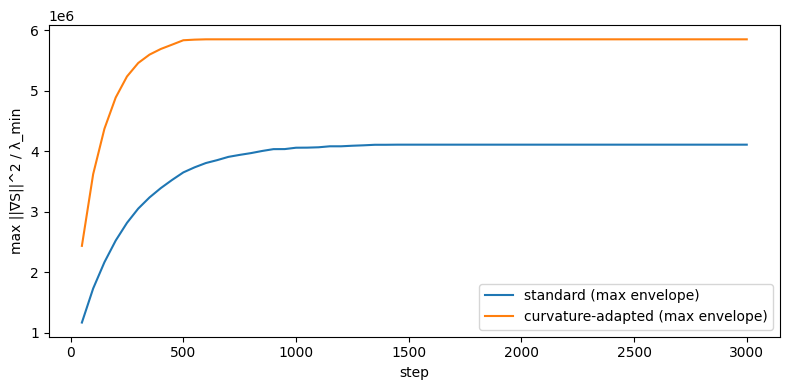

In [5]:
# ============================================================
# DRIFT PROXY COMPARISON (FIXED SYNTAX, STANDALONE CELL)
# ============================================================

import math
import torch
import torch.fft as fft
import numpy as np
import matplotlib.pyplot as plt

assert torch.cuda.is_available()
device = "cuda"
torch.set_default_dtype(torch.float64)

# ----------------------------
# PARAMETERS
# ----------------------------
L = 16
d = 4
m2 = 0.30
alpha = 1.0
lam4 = 0.5

dt = 2e-4
steps = 3000
log_every = 50
lanczos_iters = 20
eps_reg = 1e-6

# ----------------------------
# FFT MOMENTUM
# ----------------------------
freq = torch.fft.fftfreq(L, device=device)
ph = 2.0 * torch.sin(math.pi * freq)

p0 = ph.view(L,1,1,1)
p1 = ph.view(1,L,1,1)
p2 = ph.view(1,1,L,1)
p3 = ph.view(1,1,1,L)
p2grid = p0*p0 + p1*p1 + p2*p2 + p3*p3

# ----------------------------
# OPERATORS
# ----------------------------
def curlcurl(A):
    Ahat = fft.fftn(A, dim=(1,2,3,4), norm="ortho")
    dot = p0*Ahat[0] + p1*Ahat[1] + p2*Ahat[2] + p3*Ahat[3]
    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / p2grid[mask]
    fac = dot * inv
    Aperp = torch.stack([
        Ahat[0] - p0*fac,
        Ahat[1] - p1*fac,
        Ahat[2] - p2*fac,
        Ahat[3] - p3*fac,
    ], dim=0)
    return fft.ifftn(Aperp * p2grid, dim=(1,2,3,4), norm="ortho").real

def grad_S(A):
    return m2*A + alpha*curlcurl(A) + lam4*(A**3)

def hvp(A, v):
    return m2*v + alpha*curlcurl(v) + 3.0*lam4*(A*A)*v

def lambda_min_phys(A):
    q = torch.randn_like(A)
    q = q / torch.norm(q)
    q_prev = torch.zeros_like(q)
    alphas, betas = [], []
    for _ in range(lanczos_iters):
        z = hvp(A, q)
        a = (q*z).sum()
        z = z - a*q - (betas[-1]*q_prev if betas else 0)
        b = torch.norm(z)
        alphas.append(a.item())
        betas.append(b.item())
        q_prev = q
        q = z / (b + 1e-30)
    T = torch.diag(torch.tensor(alphas, device=device))
    if len(betas) > 1:
        off = torch.tensor(betas[:-1], device=device)
        T += torch.diag(off, 1) + torch.diag(off, -1)
    return torch.linalg.eigvalsh(T).min()

# ----------------------------
# RUN FUNCTION
# ----------------------------
def run(use_curvature):
    torch.manual_seed(0)
    A = 0.1 * torch.randn((d, L, L, L, L), device=device)
    ratio_log = []
    for t in range(steps):
        g = grad_S(A)
        lam = lambda_min_phys(A)
        scale = 1.0 / torch.sqrt(lam + eps_reg) if use_curvature else 1.0
        A = A - dt * scale * g + math.sqrt(2.0*dt) * scale * torch.randn_like(A)
        if (t+1) % log_every == 0:
            grad2 = (g*g).sum().item()
            ratio_log.append(grad2 / (lam.item() + eps_reg))
    return np.array(ratio_log)

# ----------------------------
# EXECUTE
# ----------------------------
r_std  = run(use_curvature=False)
r_curv = run(use_curvature=True)

x = np.arange(1, len(r_std)+1) * log_every

plt.figure(figsize=(8,4))
plt.plot(x, np.maximum.accumulate(r_std), label="standard (max envelope)")
plt.plot(x, np.maximum.accumulate(r_curv), label="curvature-adapted (max envelope)")
plt.xlabel("step")
plt.ylabel("max ||∇S||^2 / λ_min")
plt.legend()
plt.tight_layout()
plt.show()


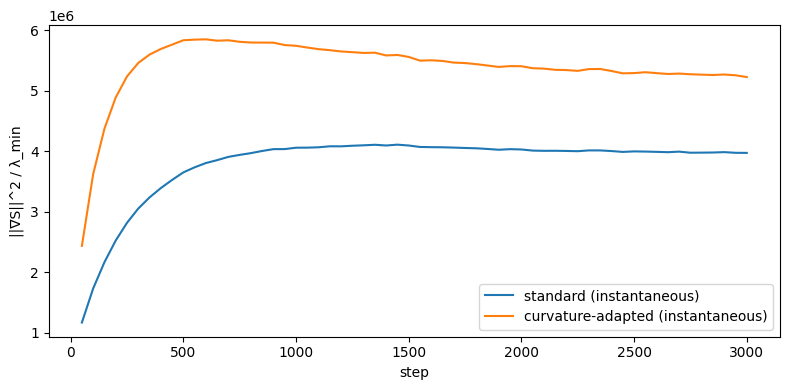

In [6]:
# ============================================================
# FIXED METRIC: INSTANTANEOUS DRIFT PROXY (NO MAX ENVELOPE)
# Compares mean(||∇S||^2 / λ_min) over time
# ============================================================

import math
import torch
import torch.fft as fft
import numpy as np
import matplotlib.pyplot as plt

assert torch.cuda.is_available()
device = "cuda"
torch.set_default_dtype(torch.float64)

# ----------------------------
# PARAMETERS (UNCHANGED)
# ----------------------------
L = 16
d = 4
m2 = 0.30
alpha = 1.0
lam4 = 0.5

dt = 2e-4
steps = 3000
log_every = 50
lanczos_iters = 20
eps_reg = 1e-6

# ----------------------------
# FFT MOMENTUM
# ----------------------------
freq = torch.fft.fftfreq(L, device=device)
ph = 2.0 * torch.sin(math.pi * freq)

p0 = ph.view(L,1,1,1)
p1 = ph.view(1,L,1,1)
p2 = ph.view(1,1,L,1)
p3 = ph.view(1,1,1,L)
p2grid = p0*p0 + p1*p1 + p2*p2 + p3*p3

# ----------------------------
# OPERATORS
# ----------------------------
def curlcurl(A):
    Ahat = fft.fftn(A, dim=(1,2,3,4), norm="ortho")
    dot = p0*Ahat[0] + p1*Ahat[1] + p2*Ahat[2] + p3*Ahat[3]
    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / p2grid[mask]
    fac = dot * inv
    Aperp = torch.stack([
        Ahat[0] - p0*fac,
        Ahat[1] - p1*fac,
        Ahat[2] - p2*fac,
        Ahat[3] - p3*fac,
    ], dim=0)
    return fft.ifftn(Aperp * p2grid, dim=(1,2,3,4), norm="ortho").real

def grad_S(A):
    return m2*A + alpha*curlcurl(A) + lam4*(A**3)

def hvp(A, v):
    return m2*v + alpha*curlcurl(v) + 3.0*lam4*(A*A)*v

def lambda_min_phys(A):
    q = torch.randn_like(A)
    q = q / torch.norm(q)
    q_prev = torch.zeros_like(q)
    alphas, betas = [], []
    for _ in range(lanczos_iters):
        z = hvp(A, q)
        a = (q*z).sum()
        z = z - a*q - (betas[-1]*q_prev if betas else 0)
        b = torch.norm(z)
        alphas.append(a.item())
        betas.append(b.item())
        q_prev = q
        q = z / (b + 1e-30)
    T = torch.diag(torch.tensor(alphas, device=device))
    if len(betas) > 1:
        off = torch.tensor(betas[:-1], device=device)
        T += torch.diag(off, 1) + torch.diag(off, -1)
    return torch.linalg.eigvalsh(T).min()

# ----------------------------
# RUN FUNCTION
# ----------------------------
def run(use_curvature):
    torch.manual_seed(0)
    A = 0.1 * torch.randn((d, L, L, L, L), device=device)
    ratio_log = []
    for t in range(steps):
        g = grad_S(A)
        lam = lambda_min_phys(A)
        scale = 1.0 / torch.sqrt(lam + eps_reg) if use_curvature else 1.0
        A = A - dt * scale * g + math.sqrt(2.0*dt) * scale * torch.randn_like(A)
        if (t+1) % log_every == 0:
            grad2 = (g*g).sum().item()
            ratio_log.append(grad2 / (lam.item() + eps_reg))
    return np.array(ratio_log)

# ----------------------------
# EXECUTE
# ----------------------------
r_std  = run(use_curvature=False)
r_curv = run(use_curvature=True)

x = np.arange(1, len(r_std)+1) * log_every

plt.figure(figsize=(8,4))
plt.plot(x, r_std, label="standard (instantaneous)")
plt.plot(x, r_curv, label="curvature-adapted (instantaneous)")
plt.xlabel("step")
plt.ylabel("||∇S||^2 / λ_min")
plt.legend()
plt.tight_layout()
plt.show()
